#### SARIMAX

SARIMA stands for Seasonal Auto Regression Integrated Moving Average with Exogenous Variables.

Exogenous variables are the external variables or the expalnatory variables.

This are the outside variables used by SARIMA model to improve the efficiency of the model.

SARIMA uses these external variables seperately to improve its productivity and efficiency.


SARIMAX can learn

    (a.)    seasonal data with repeating cyclic patterns

    (b.)    trends

    (c.)    lag relationships

    (d.)    learns the insights from the external variables.


#### Example Scenario

Suppose airline passengers depend on:

    (a.)    previous passengers

    (b.)    holiday season

    (c.)    fuel prices

Here the above are the external variables let us consider. So SARIMAX can consider it seperately to imporve its accuracy of the code.


#### Difference between ARIMA and SARIMA

| SARIMA                                           | SARIMAX                            |
| ------------------------                         | -----------------------------      |
|  past values of the target variable              | past values + external variables   |
|  no external influence                           | external influence                 |
|  univariate                                      | multivariate                       |


#### Step 1: Import all the necessary libraries


In [553]:
import      numpy                   as      np
import      pandas                  as      pd
import      matplotlib.pyplot       as      plt
import      seaborn                 as      sns


from        statsmodels.tsa.statespace.sarimax  import  SARIMAX

#### OBSERVATIONS:

1.  SARIMA ==================>  It can handle the seasonal data with the repeating cyclic patterns.

#### Step 2: Load the dataset

In [554]:
#### Load the dataset

df = pd.read_csv('AirPassengers.csv')

In [555]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


#### OBSERVATIONS:

1.  The above dataset represents the airline passengers data for the starting date of each month beginning from 1949 till 1960.

#### Create an External variable

In [556]:
#### Create an external variable named 'Promotion' in the dataset

df['Promotion'] =   np.random.randint(100,500,size=len(df))

In [557]:
df

,date,value,Promotion
0,1949-01-01,112,276
1,1949-02-01,118,246
2,1949-03-01,132,453
3,1949-04-01,129,163
4,1949-05-01,121,198
...,...,...,...
139,1960-08-01,606,189
140,1960-09-01,508,323
141,1960-10-01,461,453
142,1960-11-01,390,457


#### OBSERVATIONS:

1.  Here we have created an external variable named 'Promotion' in the dataset and it can be used exclusively and seperately by SARIMAX model to improve the efficiency of the model.

#### Step 3: Perform Data Exploration

In [558]:
#### get the first five rows of the dataset

df.head()

,date,value,Promotion
0,1949-01-01,112,276
1,1949-02-01,118,246
2,1949-03-01,132,453
3,1949-04-01,129,163
4,1949-05-01,121,198


In [559]:
#### get the last five rows of the dataset

df.tail()

,date,value,Promotion
139,1960-08-01,606,189
140,1960-09-01,508,323
141,1960-10-01,461,453
142,1960-11-01,390,457
143,1960-12-01,432,466


In [560]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 144


In [561]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (144, 3)


In [562]:
#### get the column used in the dataset

df.columns

Index(['date', 'value', 'Promotion'], dtype='object')

In [563]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       144 non-null    object
 1   value      144 non-null    int64 
 2   Promotion  144 non-null    int32 
dtypes: int32(1), int64(1), object(1)
memory usage: 2.9+ KB


#### Step 4: Perform Data Cleaning and Feature Engineering

In [564]:
#### Convert the object type of date column to date

df['date']  =   pd.to_datetime(df['date'])

In [565]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       144 non-null    datetime64[ns]
 1   value      144 non-null    int64         
 2   Promotion  144 non-null    int32         
dtypes: datetime64[ns](1), int32(1), int64(1)
memory usage: 2.9 KB


#### OBSERVATIONS:

1.  The date column has been converted from 'object' type to 'datetime' type.

In [566]:
#### To set the date column as an index

df.set_index('date',inplace=True)

In [567]:
df.head()

,value,Promotion
date,,
1949-01-01,112,276
1949-02-01,118,246
1949-03-01,132,453
1949-04-01,129,163
1949-05-01,121,198


#### OBSERVATIONS:

1.  The date column has been set as an index.

In [568]:
#### To check for the NULL records in the dataframe

df.isnull().sum()

value        0
Promotion    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [569]:
#### Rename the column name 'value' to 'Passengers'

df.rename(columns={'value':'Passengers'},inplace=True)

#### OBSERVATIONS:

1.  The column name 'value' has been renamed to 'Passenegers'.

In [570]:
df

,Passengers,Promotion
date,,
1949-01-01,112,276
1949-02-01,118,246
1949-03-01,132,453
1949-04-01,129,163
1949-05-01,121,198
...,...,...
1960-08-01,606,189
1960-09-01,508,323
1960-10-01,461,453


#### Step 5: Plot the time series data

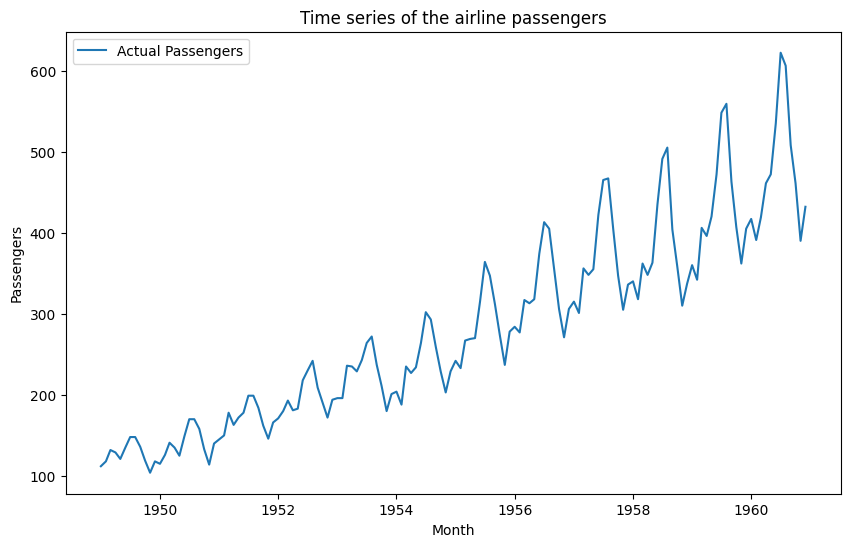

In [571]:
plt.figure(figsize=(10,6))

#### plot the original time series
plt.plot(df.index, df['Passengers'], label = 'Actual Passengers')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the passengers data for the starting date of every month starting from 1944 till 1960.

2.  With the increase in years, the number of passengers also increases, so the trned also increases.

3.  As the trend continuously increases in the upward direction, so the time series is non stationary in nature.

#### Step 6: Divide the dataset into training and testing data

In [572]:
#### Training data

train = df[:120]

In [573]:
train

,Passengers,Promotion
date,,
1949-01-01,112,276
1949-02-01,118,246
1949-03-01,132,453
1949-04-01,129,163
1949-05-01,121,198
...,...,...
1958-08-01,505,439
1958-09-01,404,298
1958-10-01,359,427


In [574]:
#### Testing data

test = df[120:]

In [575]:
test

,Passengers,Promotion
date,,
1959-01-01,360,401
1959-02-01,342,292
1959-03-01,406,391
1959-04-01,396,418
1959-05-01,420,299
1959-06-01,472,285
1959-07-01,548,247
1959-08-01,559,149
1959-09-01,463,222


#### OBSERVATIONS:

1.  The main aim of dividing the dataset into training and testing data is that

    (a.)    We train our model on the old data

    (b.)    We perform testing on the new or unseen data or any new test data.

#### Step 7: Seperate Exogenous Variables

In [576]:
#### seperate the training exogenous variables

train_exog  = train[['Promotion']]

In [577]:
train_exog

,Promotion
date,
1949-01-01,276
1949-02-01,246
1949-03-01,453
1949-04-01,163
1949-05-01,198
...,...
1958-08-01,439
1958-09-01,298
1958-10-01,427


In [578]:
#### seperate the testing exogenous variables

test_exog = test[['Promotion']]

In [579]:
test_exog

,Promotion
date,
1959-01-01,401
1959-02-01,292
1959-03-01,391
1959-04-01,418
1959-05-01,299
1959-06-01,285
1959-07-01,247
1959-08-01,149
1959-09-01,222


#### OBSERVATIONS:

1.  The main aim of seperating the external variables in the training and testing data is that

    (a.)   The SARIMAX model will use this external variable seperately to train the model and to forecast the future values seperately.

#### Step 8: Build the SARIMAX model

In [580]:
from    statsmodels.tsa.statespace.sarimax  import  SARIMAX

#### create an object for SARIMAX

sarimax = SARIMAX(
    train['Passengers']                             ,
    exog                =   train_exog              ,
    order               =   (1,1,1)                 ,
    seasonal_order      =   (1,1,1,12)
)

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### OBSERVATIONS:

1.  The object for SARIMA has been created with the following parameters :-------------

    (a.)    Input training data train['Passengers'] ===========> Model training is always done on the training data

    (b.)    exog = train_exog                      ============> extrenal training variable is needed by SARIMAX to seperately train the external training data

    (b.)    order(1,1,1)                            ===========>  ARIMA model

    (c.)    seasonal_order(1,1,1,12)                ===========>  SARIMA model as it can easily capture patterns and insights from the seasonal data with the repeating cycles.

            (i) P = 1 ===========>  Current value depends on one previous value

            (ii) D = 1 ===========>  First order of differencing is needed

            (iii) Q = 1 ===========> uses previous error term to forecast future value

            (iv)  m = 12 ===========> data repeating adter every 12 months (seasonal cycle path)

#### Step 9: Train the SARIMAX model

In [581]:
#### Train the model

model_fit = sarimax.fit()

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [582]:
model_fit

#### OBSERVATIONS:

1.  The SARIMAX model will learn

    (a.)    trends

    (b.)    seasonality

    (c.)    lags

    (d.)    effect of the external variables

#### Step 10: Get the summary of the model

In [583]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -398.841
Date:                            Thu, 28 May 2026   AIC                            809.681
Time:                                    19:03:42   BIC                            825.718
Sample:                                01-01-1949   HQIC                           816.183
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Promotion     -0.0009      0.005     -0.180      0.858      -0.010       0.008
ar.L1         -0.4292      0.377     -1.139      0.255      -1.168       0.309
ma.L1          0.1922      0.392      0.490      0.624      -0.577       0.961
ar.S.L12      -0.8754      0.454     -1.930      0.054      -1.764       0.014
ma.S.L12       0.8158      0.527      1.547      0.122      -0.218       1.849
sigma2        99.4188     13.130      7.572      0.000      73.685     125.152
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.87
Prob(Q):                              0.99   Prob(JB):                         0.39
Heteroskedasticity (H):               1.58   Skew:                            -0.04
Prob(H) (two-sided):                  0.18   Kurtosis:                         3.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### OBSERVATIONS:

1.  It describes the summary of the model

    (a.)    Promotion coefficient defines the passengers

        (i) Higher the promotion coefficient ===============> higher is the number of passengers.

#### Step 11: Forecast Future Values

In [584]:
#### create the forecast object

forecast_obj = model_fit.get_forecast(
    steps   =   len(test)               ,
    exog    =   test_exog
)

In [585]:
forecast_obj

#### OBSERVATIONS:

1.  Here test_exog (test external variables) is proided separately otherwise SARIMAX cannot forecast the values.

#### Step 12: Extract the forecast values

In [586]:
#### Extract the forecasted values

forecast_values = forecast_obj.predicted_mean

In [587]:
forecast_values

1959-01-01    342.469823
1959-02-01    320.727334
1959-03-01    366.474208
1959-04-01    353.260456
1959-05-01    367.664330
1959-06-01    438.050180
1959-07-01    494.067875
1959-08-01    507.474238
1959-09-01    408.755264
1959-10-01    362.928218
1959-11-01    312.959099
1959-12-01    340.396549
1960-01-01    344.978148
1960-02-01    323.006176
1960-03-01    367.290686
1960-04-01    353.335719
1960-05-01    368.202048
1960-06-01    440.219622
1960-07-01    495.982002
1960-08-01    510.158774
1960-09-01    409.231737
1960-10-01    364.116940
1960-11-01    314.879737
1960-12-01    341.973170
Freq: MS, Name: predicted_mean, dtype: float64

#### OBSERVATIONS:

1.  We have used the predicted mean function to forcase the airline passengers data for the last 24 months using the external testing data.

#### Step 13: Get the confidence Interval

In [588]:
#### get the confidence interval

confidence_interval = forecast_obj.conf_int()

In [589]:
confidence_interval

,lower Passengers,upper Passengers
1959-01-01,322.921851,362.017795
1959-02-01,296.140399,345.314270
1959-03-01,336.638295,396.310122
1959-04-01,319.382436,387.138477
1959-05-01,330.019243,405.309416
1959-06-01,397.044730,479.055630
1959-07-01,449.932397,538.203354
1959-08-01,460.426505,554.521971
1959-09-01,358.961262,458.549266
1959-10-01,310.533336,415.323101


#### OBSERVATIONS:

1.  We have obtained the confidence intervals for each starting date of the month ranging from 1959 till 1960.

#### Step 14: Plot the forecasted values along with the confidence intervals

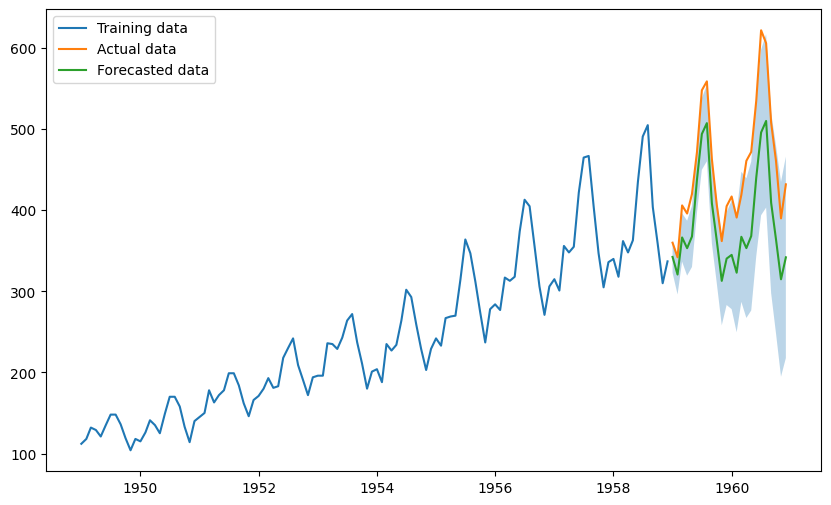

In [590]:
plt.figure(figsize=(10,6))

#### plot the original data points
plt.plot(train.index, train['Passengers'], label = 'Training data')

#### plot the actual data points
plt.plot(test.index,  test['Passengers'], label = 'Actual data')

#### plot the forecasted data points
plt.plot(test.index, forecast_values, label = 'Forecasted data')

#### plot the confidence intervals
plt.fill_between(
    test.index                                    ,
    confidence_interval.iloc[:,0]                 ,
    confidence_interval.iloc[:,1]                 ,
    alpha = 0.3
)

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  After applying SARIMAX on the above dataset, we have seen that there is an upward trend for the forecasted values.

2.  So from this, it is concluded that SARIMA has successfully captured

    (a.) trends

    (b.) lag relationships

    (c.) strong seasonality with repeating cyclic patterns in every fixed interval of time.

    (d.) strong impact of the external variable (external training and testing data).

3.  Even in the forecasting, SARIMA model can handle seasonal patterns in the data which was not in case of ARIMA model

    (a.)    In ARIMA, there was a straight line after the forecasting and the trend was removed whereas in SARIMAX, the seasonal trend still exists as it can handle the seasonal data with repeating patterns.

    (b.)    But everything in SARIMAX has been performed with respect to the exogenous variable ('promotion').

    (c.)    This variable has been trained and tested seperately and then forecasting has been done.